In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import chess.pgn
import io

In [56]:
rapid = pd.read_parquet('../data/processed/rapid/top_50_rapid.parquet')
bullet = pd.read_parquet('../data/processed/bullet/top_50_bullet.parquet')
blitz = pd.read_parquet('../data/processed/blitz/top_50_blitz.parquet')

df = pd.concat([bullet, blitz, rapid], ignore_index=True)


### 1. Durante a coleta dos dados (Partidas dos Top 50 jogadores) percebi que as partidas de Bullet e Blitz rapidamente eram coletadas, enquanto as de Rapid demoravam mais, precisavam ir mais longe no tempo para conseguir todas as 200 partidas

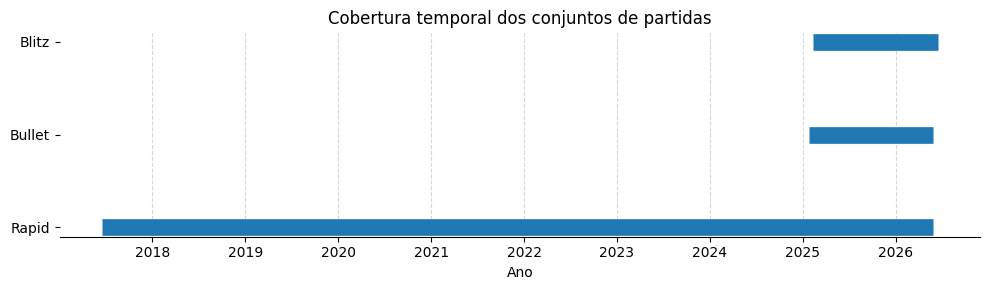

In [57]:
# Datas inicial e final por modalidade
periodos = (
    df.groupby("time_class")["end_time"]
      .agg(inicio="min", fim="max")
      .sort_values("inicio")
)

# Criar figura
fig, ax = plt.subplots(figsize=(10, 3))

# Desenhar uma linha para cada modalidade
for i, (game_mode, row) in enumerate(periodos.iterrows()):
    ax.hlines(
        y=i,
        xmin=row["inicio"],
        xmax=row["fim"],
        linewidth=12,
        label=game_mode.capitalize()
    )

# Eixo Y
ax.set_yticks(range(len(periodos)))
ax.set_yticklabels([m.capitalize() for m in periodos.index])

# Eixo X
ax.set_xlabel("Ano")
ax.set_title("Cobertura temporal dos conjuntos de partidas")
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Remover bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

Com esse gráfico é perceptível que a coleta das partidas de Bullet e de Blitz, tiveram uma faixa de ~1 ano para conseguir as 200 partidas

Já as partidas de Rapid, preciram ir até 2017, para coletar todas as partidas

---

O que é um bom indicativo de que os Top Players do mundo, constumam jogar muito mais partidas Bullet e Blitz do que Rapid

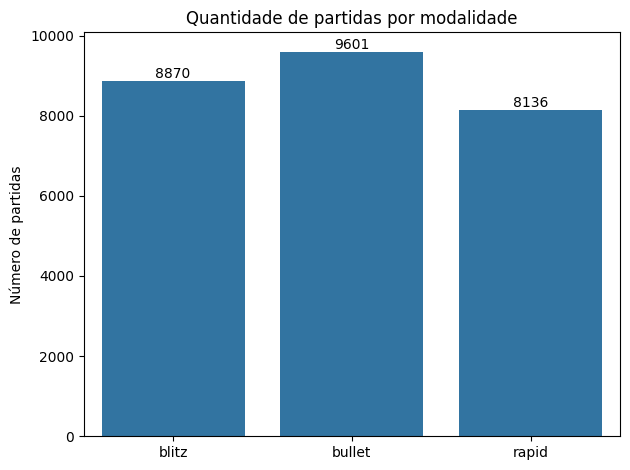

In [91]:
# DF temporário para a contagem das partidas
df_count = (
    df.groupby("time_class")["time_class"]
      .count()
      .reset_index(name="match_count")
)

# Criar figura
ax = sns.barplot(
    data=df_count,
    x="time_class",
    y="match_count"
)

ax.set_title("Quantidade de partidas por modalidade")
ax.set_xlabel("")
ax.set_ylabel("Número de partidas")

# Mostrar o valor acima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

Nesse gráfico de barras, da para ver claramente essa diferença no valor bruto. 

- Rapid com 8136 partidas, de um total esperado de 10000.
    
    Ou seja, mesmo buscando partidas em um intervalo de ~9 anos, alguns players não tiveram 200 partidas na conta

- Bullet com 9601 partidas e Blitz com 8870, de um total esperado de 10000.

    Se aproximou do valor total, mas em alguns casos também não alcançaram as 200 partidas totais por jogadores

### 2. Quais eventos disputados? Apenas Live Chess ou algum torneio?

In [92]:
# Extrair o nome do evento com um regex dos valores do pgn
df["event"] = df["pgn"].str.extract(r'\[Event\s+"([^"]+)"\]')
df.groupby("time_class")["event"].value_counts()

time_class  event     
blitz       Live Chess    8870
bullet      Live Chess    9601
rapid       Live Chess    8136
Name: count, dtype: int64

Apenas Live Chess em todas as partidas do Dataset, lembrando que todas as partidas são Rated, pois foram filtradas na hora da coleta

### 3. Em média, quantos lances tem nas partidas de Rapid e quantos tem nas partidas de Bullet?

In [93]:
# Extrair a quantidade de lances totais, usando python-chess para percorrer o pgn
def get_num_moves_chess(pgn):
    game = chess.pgn.read_game(io.StringIO(pgn))
    return game.end().board().fullmove_number - (
        1 if game.end().board().turn == chess.WHITE else 0
    )

df["moves_count"] = df["pgn"].apply(get_num_moves_chess)